In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import timm
import matplotlib.pyplot as plt
from utils import do_2D_pca
from PIL import Image
from utils import load_image, resize_crop
# DINOv2
#dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg').to("cuda")
#dinov2_vits14.eval()

from vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_MAP,
    FeatureType,
    MODEL_LIST,
)

vit_wrapper = PretrainedViTWrapper(MODEL_LIST[1], add_flash_attn=True, device="cuda")

## Where to find the positional encoding

In [2]:
vit_wrapper.model.pos_embed.shape

torch.Size([1, 1369, 384])

Changing it

In [47]:
def get_sinusoid_encoding(num_tokens, token_len):
    """ Make Sinusoid Encoding Table

        Args:
            num_tokens (int): number of tokens
            token_len (int): length of a token
            
        Returns:
            (torch.FloatTensor) sinusoidal position encoding table
    """

    def get_position_angle_vec(i):
        return [i / np.power(10000, 2 * (j // 2) / token_len) for j in range(token_len)]

    sinusoid_table = np.array([get_position_angle_vec(i) for i in range(num_tokens)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2]) 

    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

In [48]:
new_pos_embedding = get_sinusoid_encoding(1369, 384).to(torch.float16) # needs to have the shape [1, 1369, 384]

In [49]:
new_pos_embedding

tensor([[[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
           0.0000e+00,  1.0000e+00],
         [ 8.4131e-01,  5.4053e-01,  8.1543e-01,  ...,  1.0000e+00,
           1.0490e-04,  1.0000e+00],
         [ 9.0918e-01, -4.1626e-01,  9.4434e-01,  ...,  1.0000e+00,
           2.0981e-04,  1.0000e+00],
         ...,
         [ 5.5859e-01, -8.2959e-01,  9.8535e-01,  ...,  9.8877e-01,
           1.4282e-01,  9.8975e-01],
         [-3.9600e-01, -9.1846e-01,  7.0947e-01,  ...,  9.8877e-01,
           1.4294e-01,  9.8975e-01],
         [-9.8682e-01, -1.6284e-01, -1.6382e-01,  ...,  9.8877e-01,
           1.4307e-01,  9.8975e-01]]], dtype=torch.float16)

to add a different embedding one needs to delete the original pos_embed beforehand

In [50]:
del vit_wrapper.model.pos_embed
vit_wrapper.model.pos_embed = new_pos_embedding.to("cuda")

In [51]:
vit_wrapper.eval()

PretrainedViTWrapper(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
  

In [52]:
white_img = np.ones((518,518), np.float16)
white_img_unsq = torch.tensor(white_img).unsqueeze(0).unsqueeze(0).repeat([1,3,1,1])
white_img_unsq.shape

torch.Size([1, 3, 518, 518])

In [53]:
black_dog = load_image("black_dog.jpg", resize_crop((518,518), (518,518)))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9296875..2.640625].


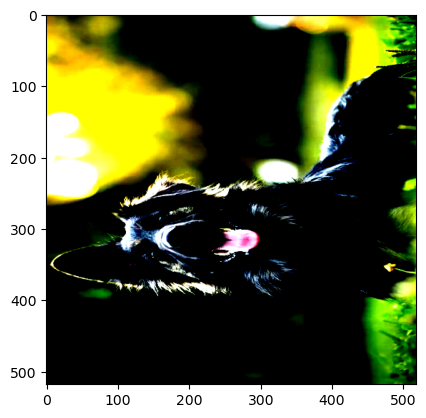

In [54]:
plt.imshow(black_dog[0].cpu().squeeze().transpose(0,2).float())

In [57]:
res = vit_wrapper.forward_features(white_img_unsq.to("cuda"), make_2D=True)
#res = vit_wrapper.forward_features(black_dog[0].to("cuda"), make_2D=True)

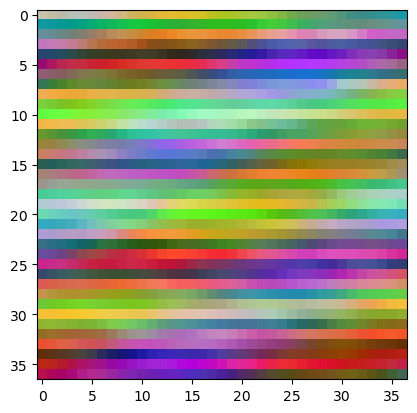

In [58]:
reduced_feats = do_2D_pca(res[0,::], n_components=3, post_norm="minmax")
plt.imshow(reduced_feats)

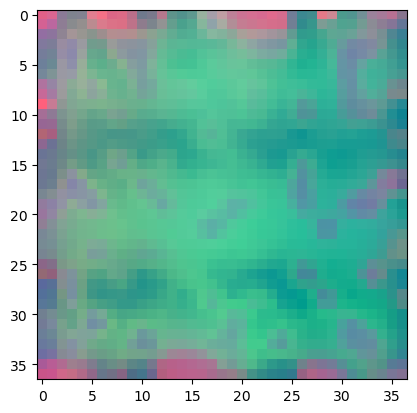

In [40]:
plt_img = np.transpose(res.detach().cpu().numpy().squeeze()[[1,4,10],:,:], (2,1,0)).astype(np.float32)

scaled_plt_img = ((plt_img - plt_img.min())/(plt_img.max()-plt_img.min()))
plt.imshow(scaled_plt_img)

(array([3.0000e+00, 2.0000e+00, 2.0000e+00, 4.0000e+00, 0.0000e+00,
        1.0000e+00, 4.0000e+00, 1.0000e+00, 2.0000e+00, 1.0000e+00,
        3.0000e+00, 2.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00,
        4.0000e+00, 1.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 2.0000e+00, 6.0000e+00, 5.0000e+00, 2.0000e+00,
        5.0000e+00, 8.0000e+00, 7.0000e+00, 1.6000e+01, 2.0000e+01,
        1.2000e+01, 1.2000e+01, 1.4000e+01, 2.4000e+01, 1.6000e+01,
        2.1000e+01, 2.0000e+01, 3.0000e+01, 3.8000e+01, 3.0000e+01,
        4.5000e+01, 3.3000e+01, 4.4000e+01, 4.8000e+01, 3.6000e+01,
        3.4000e+01, 3.3000e+01, 3.6000e+01, 3.9000e+01, 3.1000e+01,
        4.7000e+01, 5.6000e+01, 5.8000e+01, 4.6000e+01, 4.8000e+01,
        3.6000e+01, 4.7000e+01, 4.5000e+01, 4.9000e+01, 6.5000e+01,
        8.2000e+01, 1.3400e+02, 1.4200e+02, 2.0000e+02, 2.8400e+02,
        3.4400e+02, 4.3500e+02, 5.0300e+02, 6.5200e+02, 9.0400e+02,
        9.9400e+02, 1.1320e+03, 1.5970e+03, 2.26

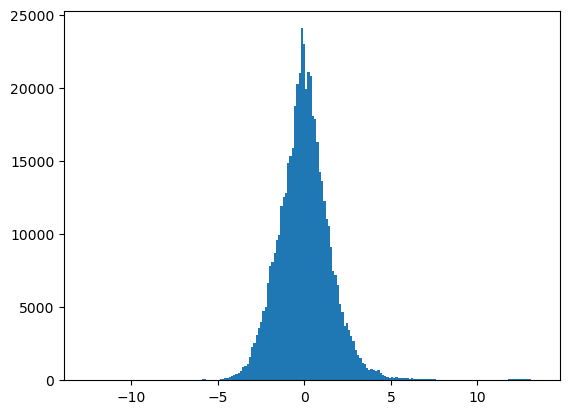

In [ ]:
#plt.hist(res.flatten().detach().cpu().numpy(), bins=200)